imports

In [1]:
import mysql.connector
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data_dir = Path("../Data")
input_file = data_dir / "bank_dataset_transformed_2026-06-29.csv"

df = pd.read_csv(input_file, encoding="utf-8-sig")

print(f"Dataset loaded from: {input_file.resolve()}")
print(f"Shape: {df.shape}")

df.head(10)

Dataset loaded from: C:\Users\elisa\Documents\Simulador\ProjecteData\Equip_32\Data\bank_dataset_transformed_2026-06-29.csv
Shape: (10630, 28)


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3
5,6,42.0,management,single,tertiary,no,0,yes,yes,unknown,...,1,0,Adult (36-50),2,Medium burden,3.0,Tertiary,White Collar,1,0-3
6,7,56.0,management,married,tertiary,no,830,yes,yes,unknown,...,1,0,Middle-Aged (51-65),2,Medium burden,3.0,Tertiary,White Collar,1,0-3
7,8,60.0,retired,divorced,secondary,no,545,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Retired,1,0-3
8,9,37.0,technician,married,secondary,no,1,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
9,10,28.0,services,single,secondary,no,5090,yes,no,unknown,...,1,0,Young Adult (26-35),1,Low burden,2.0,Secondary,Blue Collar,1,0-3


### Business Question

Which demographic characteristics are associated with a higher probability of subscribing to a term deposit?

### Analytical approach

This analysis focuses on demographic variables only. First, each demographic characteristic is evaluated individually. Then, the variables are combined to identify customer segments with the highest subscription rates.

In [3]:
# Reusable function to analyze demographic variables consistently.
# The function generates both a summary table and a bar chart.

def analyze_profile_variable(df, variable, order=None, sort=False, reverse_palette=False):

# Compute subscription rates and sample size for each demographic category
   
    summary = (
        df.groupby(variable, observed=True)["deposit"]
          .value_counts(normalize=True)
          .unstack()
          .mul(100)
          .rename(columns={
              1: "subscription_rate",
              0: "non_subscription_rate"
          })
          .round(1)
    )

    summary["n_clients"] = (
        df.groupby(variable, observed=True)
          .size()
    )

# Display the categories in a clear order

    if order is not None:
        summary = summary.reindex(order)
    elif sort:
        summary = summary.sort_values(
            by="subscription_rate",
            ascending=False
        )

    display(summary)

# Create a consistent colour palette for all demographic charts

    if reverse_palette:
        colors = ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"]
    else:
        colors = ["#1F5C45", "#4F8A6A", "#8DB79A", "#DDEFE6"]

    palette = sns.blend_palette(
        colors,
        n_colors=summary.shape[0]
    )

    plt.figure(figsize=(10,5))

    # Visualize subscription rates across demographic categories

    sns.barplot(
    data=summary.reset_index(),
    x=variable,
    y="subscription_rate",
    hue=variable,
    order=summary.index,
    hue_order=summary.index,
    palette=palette,
    legend=False,
    width=0.8,
    dodge=False
)

    plt.title(f"Deposit Subscription Rate by {variable.replace('_',' ').title()}")
    plt.xlabel(variable.replace("_"," ").title())
    plt.ylabel("Subscription Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

### Age

Age is analysed first to determine whether subscription behaviour changes across different stages of life.

deposit,non_subscription_rate,subscription_rate,n_clients
age_group,,,
Senior (65+),18.6,81.4,392
Young (18-25),27.0,73.0,437
Middle-Aged (51-65),49.6,50.4,1969
Young Adult (26-35),50.0,50.0,3735
Adult (36-50),56.4,43.6,4097


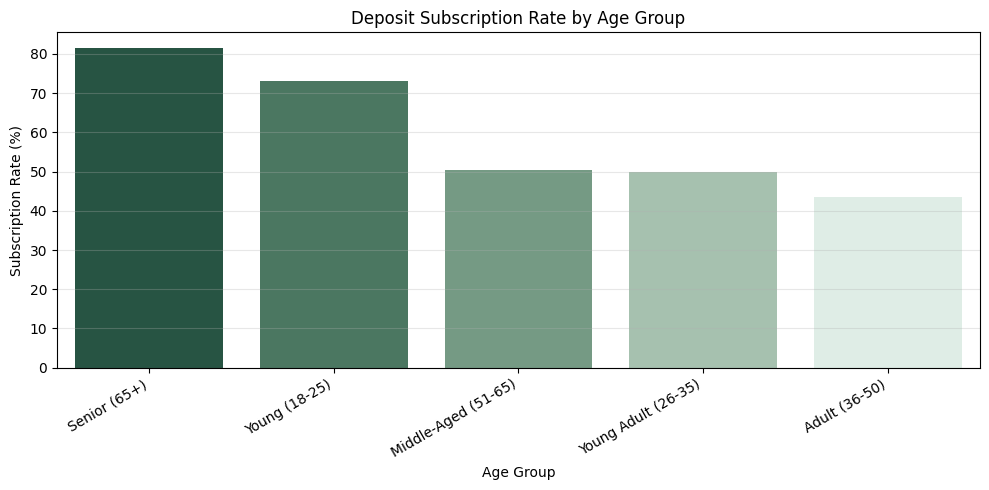

In [4]:
age_order = [
    "Young (18-25)",
    "Young Adult (26-35)",
    "Adult (36-50)",
    "Middle-Aged (51-65)",
    "Senior (65+)"
]

analyze_profile_variable(df, "age_group", sort=True)

Customers aged 60 and over present the highest conversion rate (around 78%), suggesting that older clients are considerably more likely to subscribe to a term depo
sit than younger age groups. This may be related to greater financial stability or more conservative investment preferences, although further analysis would be required to confirm these factors.


### Job profile

Occupational groups are compared to identify whether employment status influences customers' propensity to subscribe.

deposit,non_subscription_rate,subscription_rate,n_clients
job_profile,,,
Student,24.1,75.9,353
Retired,31.7,68.3,754
Unemployed/Unknown,41.9,58.1,406
White Collar,49.3,50.7,5456
Self-Employed,55.4,44.6,695
Blue Collar,60.0,40.0,2966


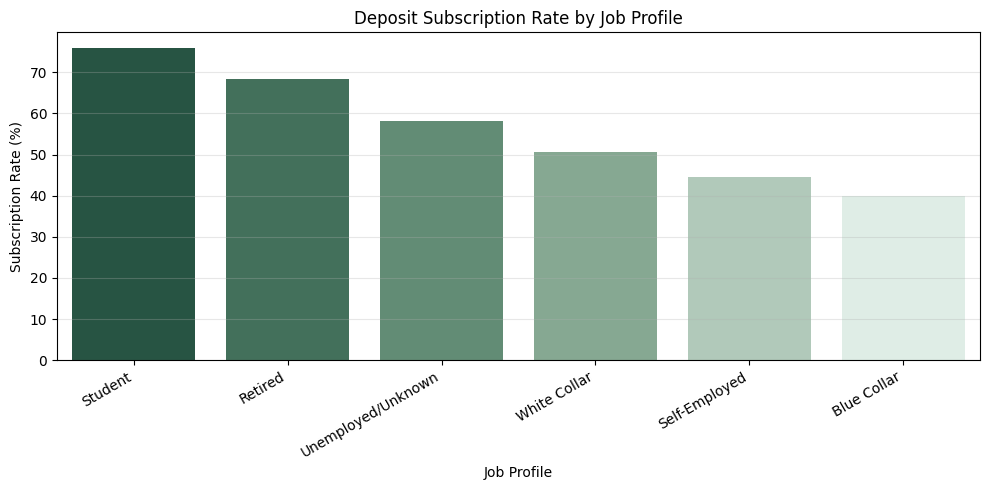

In [5]:
analyze_profile_variable(df, "job_profile", sort=True)

Students and retired customers exhibit the highest subscription rates, while operational occupations show the lowest conversion.
This suggests that employment profile is an important differentiating factor in customer behaviour.

In [6]:
pd.crosstab(
    df["job"],
    df["deposit"],
    normalize="index"
).mul(100).round(1)

deposit,0,1
job,,
admin.,50.6,49.4
blue-collar,61.3,38.7
entrepreneur,59.9,40.1
housemaid,57.6,42.4
management,46.9,53.1
retired,31.7,68.3
self-employed,51.8,48.2
services,58.1,41.9
student,24.1,75.9


### Education

Education level is evaluated as a potential indicator of financial behaviour and product adoption.

deposit,non_subscription_rate,subscription_rate,n_clients
education_label,,,
Tertiary,43.5,56.5,3526
Unknown,46.7,53.3,473
Secondary,53.1,46.9,5214
Primary,58.3,41.7,1417


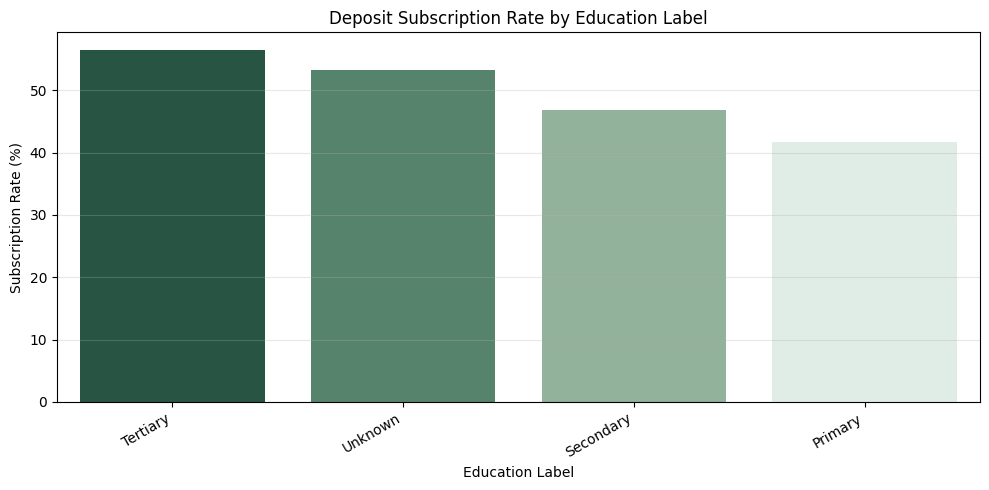

In [7]:
analyze_profile_variable(df, "education_label", sort=True)

Customers with tertiary education consistently achieve the highest subscription rates, whereas secondary education records the lowest conversion. The results suggest a positive association between education level and deposit subscription.

### Marital Status

Marital status is analysed to assess whether customers’ family situation is associated with different subscription rates.

deposit,non_subscription_rate,subscription_rate,n_clients
marital,,,
single,43.4,56.6,3370
divorced,49.7,50.3,1233
married,54.3,45.7,6027


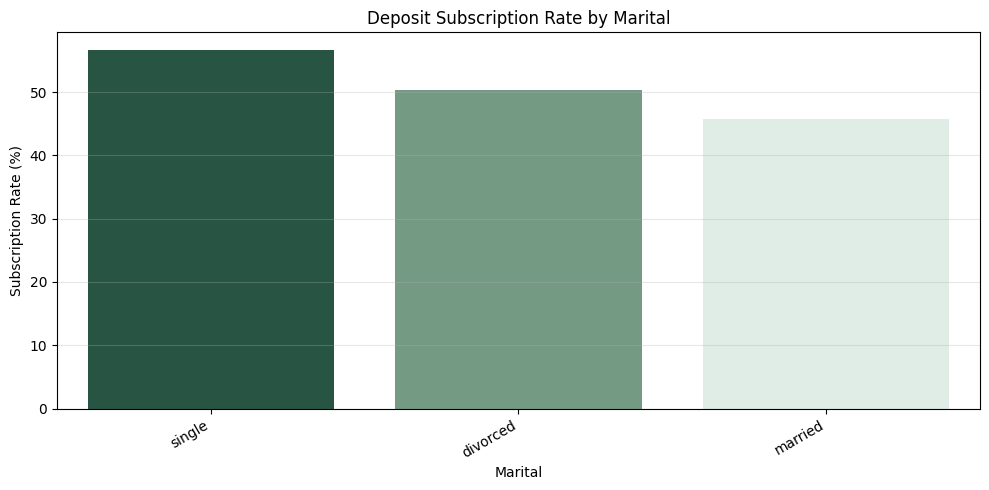

In [8]:
analyze_profile_variable(df, "marital", sort=True)

Single customers show the highest subscription rate, while married customers present the lowest conversion. This suggests that marital status may be associated with different financial priorities and product adoption behaviour.

### Age x Job

Combining demographic variables provides a more detailed customer profile than analysing each characteristic separately. The heatmap highlights the interaction between age and occupation.

In [9]:
summary = (
    df.groupby(["age_group", "job_profile"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={1: "subscription_rate",
                       0: "non_subscription_rate"})
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["age_group", "job_profile"], observed=True)
      .size()
)

display(summary)

deposit                                 non_subscription_rate  \
age_group           job_profile                                 
Adult (36-50)       Blue Collar                          63.6   
                    Retired                              70.6   
                    Self-Employed                        60.9   
                    Student                              36.4   
                    Unemployed/Unknown                   47.2   
                    White Collar                         52.4   
Middle-Aged (51-65) Blue Collar                          61.0   
                    Retired                              41.5   
                    Self-Employed                        57.9   
                    Unemployed/Unknown                   37.0   
                    White Collar                         47.2   
Senior (65+)        Blue Collar                          21.4   
                    Retired                              18.8   
                    Self-Employed                         NaN   
                    Unemployed/Unknown                   50.0   
                    White Collar                         13.6   
Young (18-25)       Blue Collar                          32.4   
                    Self-Employed                        21.4   
                    Student                              18.8   
                    Unemployed/Unknown                   16.7   
                    White Collar                         35.1   
Young Adult (26-35) Blue Collar                          58.3   
                    Retired                               NaN   
                    Self-Employed                        50.4   
                    Student                              28.7   
                    Unemployed/Unknown                   38.7   
                    White Collar                         48.1   

deposit                                 subscription_rate  n_clients  
age_group           job_profile                                       
Adult (36-50)       Blue Collar                      36.4       1326  
                    Retired                          29.4         17  
                    Self-Employed                    39.1        304  
                    Student                          63.6         22  
                    Unemployed/Unknown               52.8        180  
                    White Collar                     47.6       2248  
Middle-Aged (51-65) Blue Collar                      39.0        474  
                    Retired                          58.5        390  
                    Self-Employed                    42.1        133  
                    Unemployed/Unknown               63.0         92  
                    White Collar                     52.8        880  
Senior (65+)        Blue Collar                      78.6         14  
                    Retired                          81.2        346  
                    Self-Employed                   100.0          6  
                    Unemployed/Unknown               50.0          4  
                    White Collar                     86.4         22  
Young (18-25)       Blue Collar                      67.6        102  
                    Self-Employed                    78.6         14  
                    Student                          81.2        181  
                    Unemployed/Unknown               83.3          6  
                    White Collar                     64.9        134  
Young Adult (26-35) Blue Collar                      41.7       1050  
                    Retired                         100.0          1  
                    Self-Employed                    49.6        238  
                    Student                          71.3        150  
                    Unemployed/Unknown               61.3        124  
                    White Collar                     51.9       2172

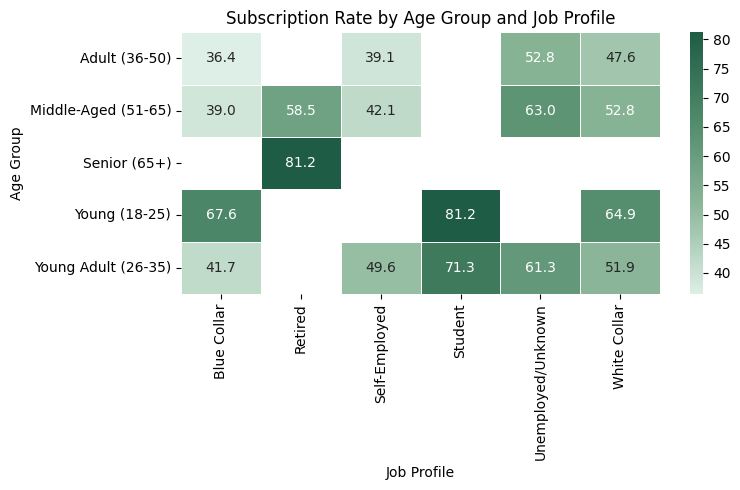

In [10]:
summary_filtered = summary.copy()
summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

heatmap_data = summary_filtered["subscription_rate"].unstack()
plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Age Group and Job Profile")
plt.xlabel("Job Profile")
plt.ylabel("Age Group")

plt.tight_layout()
plt.show()

Students and retired customers consistently present the highest subscription rates, whereas operational occupations remain the weakest-performing group across most age segments. Results from very small groups should be interpreted cautiously. Cells with missing values represent combinations with insufficient observations and were excluded from interpretation.

### Education × Marital

A second multivariate analysis explores whether education and marital status jointly influence subscription behaviour.

In [11]:
summary = (
    df.groupby(["education_label", "marital"], observed=True)["deposit"]
      .value_counts(normalize=True)
      .unstack()
      .mul(100)
      .rename(columns={
          1: "subscription_rate",
          0: "non_subscription_rate"
      })
      .round(1)
)

summary["n_clients"] = (
    df.groupby(["education_label", "marital"], observed=True)
      .size()
)

display(summary)

deposit                   non_subscription_rate  subscription_rate  n_clients
education_label marital                                                      
Primary         divorced                   47.5               52.5        198
                married                    61.7               38.3       1035
                single                     50.5               49.5        184
Secondary       divorced                   53.5               46.5        621
                married                    56.0               44.0       2965
                single                     47.5               52.5       1628
Tertiary        divorced                   44.7               55.3        367
                married                    48.0               52.0       1754
                single                     37.5               62.5       1405
Unknown         divorced                   48.9               51.1         47
                married                    48.0               52.0        273
                single                     43.8               56.2        153

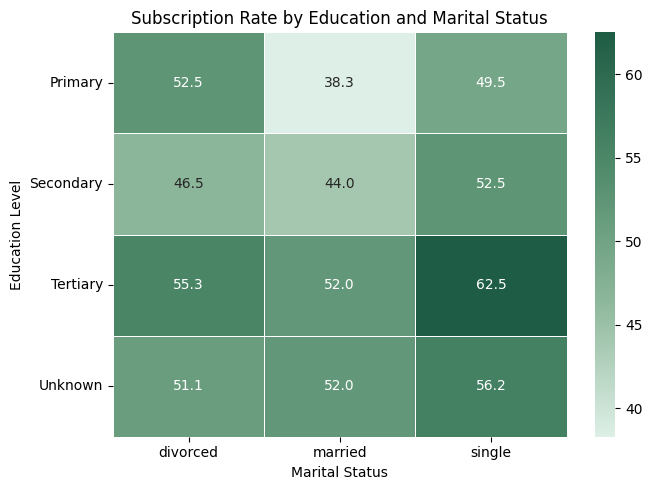

In [12]:
# filter small groups

summary_filtered = summary.copy()

summary_filtered.loc[
    summary_filtered["n_clients"] < 30,
    "subscription_rate"
] = np.nan

# heatmap

heatmap_data = summary_filtered["subscription_rate"].unstack()

# order

education_order = [
    "Primary",
    "Secondary",
    "Tertiary",
    "Unknown"
]

heatmap_data = heatmap_data.reindex(education_order)

plt.figure(figsize=(7,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap=sns.blend_palette(
        ["#DDEFE6", "#8DB79A", "#4F8A6A", "#1F5C45"],
        as_cmap=True
    ),
    linewidths=0.5
)

plt.title("Subscription Rate by Education and Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Education Level")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Subscription rates tend to increase with higher education levels, especially among single customers. Married customers with primary or secondary education show the lowest conversion rates, while single customers with tertiary education exhibit the highest subscription rate (62.5%).

## Business Conclusions

### Key findings

Older customers, students and retired clients exhibit the highest subscription rates.
Tertiary education is consistently associated with higher conversion.
Multivariate analysis confirms that demographic characteristics interact, producing customer segments with substantially different subscription behaviour.

The analysis indicates that the most favourable customer profile combines higher education, single marital status, and demographic segments such as students or retirees, which consistently achieve the highest subscription rates across the analyses.

### Business implication

Demographic profiling can support more targeted marketing campaigns by identifying customer segments with the highest likelihood of subscribing to a term deposit.